In [1]:
import logging
from tqdm.notebook import tqdm
import pandas as pd
import numpy as np
import pandas as pd
import os
import pickle
from datetime import datetime
from ts_toolkit.pipeline.runner import TsPipeline
from ts_toolkit.pipeline.utils import load_config

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
logging.basicConfig(level=logging.INFO)


/Users/gstein/src/timeseries-research/.venv/lib/python3.11/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore


In [2]:
%load_ext autoreload
%autoreload 2

### Data saving for plotting purposes

In [3]:
def forecast_output_saver(pipeline, multivariate_str, model_name, output_file):
    output_list = pipeline.output_forecast_generator()

    output_data = {multivariate_str: {model_name: {}}}
    # write the outputs to a json/pickle file
    for output in output_list:
        input_list, label_list, forecast_list, data, item_id, dataset_label = output
        if dataset_label not in output_data[multivariate_str][model_name]:
            output_data[multivariate_str][model_name][dataset_label] = {}
        
        output_data[multivariate_str][model_name][dataset_label][item_id] = {
            "dataset_label": dataset_label,
            "input_list": input_list,
            "label_list": label_list,
            "forecast_list": forecast_list,
            "data": data,
            "item_id": item_id,
        }
                
    # append to existing file or create new
    if os.path.exists(output_file):
        with open(output_file, "rb") as f:
            loaded_output_data = pickle.load(f)
    else:
        loaded_output_data = {}

    # deep merge two dictionaries
    for mv_key in output_data.keys():
        if mv_key not in loaded_output_data:
            loaded_output_data[mv_key] = {}
        for model_key in output_data[mv_key].keys():
            if model_key not in loaded_output_data[mv_key]:
                loaded_output_data[mv_key][model_key] = {}
            for dataset_key in output_data[mv_key][model_key].keys():
                if dataset_key not in loaded_output_data[mv_key][model_key]:
                    loaded_output_data[mv_key][model_key][dataset_key] = {}
                for item_id_key, item_data in output_data[mv_key][model_key][dataset_key].items():
                    loaded_output_data[mv_key][model_key][dataset_key][item_id_key] = item_data
            
    with open(output_file, "wb") as f:
        pickle.dump(loaded_output_data, f)
    
    return loaded_output_data

In [4]:
POLISHED_PATH = f"results/polished_outputs/{datetime.now().strftime('%Y%m%d_%H%M%S')}/forecast_outputs.pkl"
os.makedirs(os.path.dirname(POLISHED_PATH), exist_ok=True)

In [ ]:
model_repertoire = {
    # "Chronos2": {"name": "Chronos2", "params": { "batch_size": 8}},
    # "Moirai": {"name": "Moirai", "params": {"repo_id": "Salesforce/moirai-1.1-R-large", "batch_size": 8}},
    "Toto": {"name": "Toto", "params": {"context_length": 4_096, "batch_size": 8}},
    # "Sundial": {"name": "Sundial", "params": { "batch_size": 64}},
}

config_dict = {
    "paths": {
        "storage_path": "data/simpletime/datasets",
        "output_path": "tmp_results"
    },
    "forecaster": None,
    "evaluation": {
        "to_univariate": False,
        "show_plot": False,
        "eval_substr": "dim0"
    },
}

for multivariate in [False, True]:
    if multivariate:
        multivariate_str = "Multivariate"
        config_dict["datasets"] = [
            {"name": "multivariate_lagged/normal", "term": "short"},
            {"name": "multivariate_lagged/random_walk", "term": "short"},
            {"name": "multivariate_lagged/intermittent", "term": "short"},
        ]
    else:
        multivariate_str = "Univariate"
        config_dict["datasets"] = [
            {"name": "univariate/linear", "term": "short"},
            {"name": "univariate/exponential", "term": "short"},
            {"name": "univariate/staircase", "term": "short"},
            {"name": "univariate/sine", "term": "short"},
            {"name": "univariate/fourier", "term": "short"},
            {"name": "univariate/growing_sine", "term": "short"},
        ]
        
    for model_name in model_repertoire.keys():
        config_dict["forecaster"] = {
            "name": "MedianEnsemble",
            "max_length": 512,
            "models": [model_repertoire[model_name]],
            "alias": f"{model_name}-{multivariate_str}-Full-Simpletime" # An identifier for your ensemble
        }
        config_dict["experiment_name"] = f"simpletime_{multivariate_str}_Full"
        config_dict["evaluation"]["to_univariate"] = not multivariate
        
        config = load_config(config_dict=config_dict) # config_path

        # --- Set up the evaluation pipeline ---
        pipeline = TsPipeline(config)
        # print(pipeline.get_forecast_horizons())
        pipeline.run(skip_existing=False, num_plots=1)
        # pipeline.get_results()
        agg_output_pickle = forecast_output_saver(pipeline, multivariate_str, model_name, POLISHED_PATH)
        print('Datasets: ', agg_output_pickle[multivariate_str][model_name].keys())
        

INFO:ts_toolkit.pipeline.runner:   - Results will be saved to: /Users/gstein/src/timeseries-research/tmp_results/simpletime_Univariate_Full_20260211-124614/Toto-Univariate-Full-Simpletime
INFO:ts_toolkit.pipeline.runner:   - Datasets will be loaded from: /Users/gstein/src/timeseries-research/data/simpletime/datasets

INFO:ts_toolkit.pipeline.runner:
--- Starting Evaluation ---


Evaluating Datasets:   0%|          | 0/6 [00:00<?, ?it/s]

INFO:ts_toolkit.pipeline.eval:Dataset 'univariate/linear' has target_dim=1 => to_univariate is forced set to False.


config.json:   0%|          | 0.00/582 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

  2026-02-11T20:47:18.237034Z ERROR  Python exception updating progress:, error: PyErr { type: <class 'LookupError'>, value: LookupError(<ContextVar name='shell_parent' at 0x103aa8cc0>), traceback: Some(<traceback object at 0x330a27640>) }, caller: "src/progress_update.rs:313"
    at /Users/runner/work/xet-core/xet-core/error_printer/src/lib.rs:28



In [18]:
pipeline.evaluator.target_dim

AttributeError: 'TsPipeline' object has no attribute 'evaluator'

In [70]:
np.asanyarray(agg_output_pickle['Univariate']['Chronos2']['univariate/exponential']['exponential_sample_000000']['input_list']).shape

(1, 226)

In [71]:
POLISHED_PATH

'results/polished_outputs/20260211_095328/forecast_outputs.pkl'

In [72]:
# read the outputs from the file
# POLISHED_PATH = f"results/polished_outputs/20260210_124936/forecast_outputs.pkl"
with open(POLISHED_PATH, "rb") as f:
    output_data = pickle.load(f)

for k, v in output_data.items():
    print(k, v.keys())
    # print a sample of the data
    for model_name, model_data in v.items():
        print(f"    Model: {model_name} w/ datasets: {model_data.keys()}")
        for dataset_name, dataset_data in model_data.items():
            for item_id, item_data in dataset_data.items():
                print(f"        Dataset: {dataset_name}")
                print(f"            item_id: {item_data['item_id']}")
                print(f"            dataset_label: {item_data['dataset_label']}")
                print(f"            Input sample shape: {np.array(item_data['input_list']).shape}")
                print(f"            Label sample shape: {np.array(item_data['label_list']).shape}")
                print(f"            Forecast sample length: {len(item_data['forecast_list'])}")
                break

Univariate dict_keys(['Chronos2', 'Moirai', 'Toto'])
    Model: Chronos2 w/ datasets: dict_keys(['univariate/linear', 'univariate/exponential', 'univariate/staircase', 'univariate/sine', 'univariate/fourier', 'univariate/growing_sine'])
        Dataset: univariate/linear
            item_id: linear_sample_000000
            dataset_label: univariate/linear
            Input sample shape: (1, 226)
            Label sample shape: (1, 30)
            Forecast sample length: 1
        Dataset: univariate/exponential
            item_id: exponential_sample_000000
            dataset_label: univariate/exponential
            Input sample shape: (1, 226)
            Label sample shape: (1, 30)
            Forecast sample length: 1
        Dataset: univariate/staircase
            item_id: staircase_sample_000000
            dataset_label: univariate/staircase
            Input sample shape: (1, 226)
            Label sample shape: (1, 30)
            Forecast sample length: 1
        Dataset:

linear_sample_000004 selected.
exponential_sample_000000 selected.
staircase_sample_000004 selected.
sine_sample_000008 selected.
fourier_sample_000004 selected.
growing_sine_sample_000007 selected.
linear_sample_000004 selected.
exponential_sample_000000 selected.
staircase_sample_000004 selected.
sine_sample_000008 selected.
fourier_sample_000004 selected.
growing_sine_sample_000007 selected.
linear_sample_000004 selected.
exponential_sample_000000 selected.
staircase_sample_000004 selected.
sine_sample_000008 selected.
fourier_sample_000004 selected.
growing_sine_sample_000007 selected.
normal_sample_000002 selected.
random_walk_sample_000003 selected.
intermittent_sample_000000 selected.
normal_sample_000002 selected.
random_walk_sample_000003 selected.
intermittent_sample_000000 selected.
normal_sample_000002 selected.
random_walk_sample_000003 selected.
intermittent_sample_000000 selected.


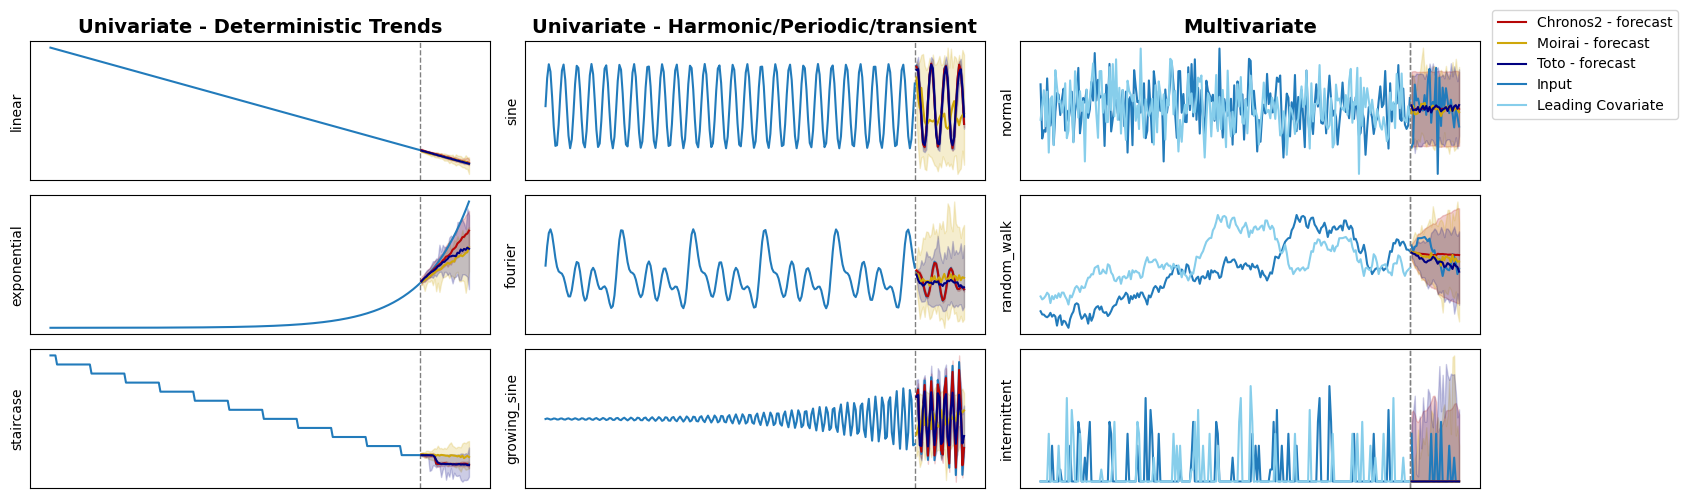

In [114]:
import matplotlib.pyplot as plt

YELLOW = "#F8E796"
DARK_YELLOW = "#CFA70A"
BLUE = "#227bbb"
SKY_BLUE = '#87ceeb'
NAVY = '#000080'
DARK_RED = '#8b0000'
RED = "#B60707"
FOREST_GREEN = "#064306"
GREEN = '#2ca02c'
GRAY = '#808080'
colors = {
    "input": BLUE, "leading_covariate": SKY_BLUE, "boundary": GRAY,
    "Chronos2": RED, "Toto": NAVY, "Moirai": DARK_YELLOW
}
shade = True

selected_data_ids = {
    "multivariate_lagged/normal": "normal_sample_000002",
    "multivariate_lagged/random_walk": "random_walk_sample_000003",
    "multivariate_lagged/intermittent": "intermittent_sample_000000",
    "univariate/linear": "linear_sample_000004",
    "univariate/exponential": "exponential_sample_000000",
    "univariate/staircase": "staircase_sample_000004",
    "univariate/sine": "sine_sample_000008",
    "univariate/fourier": "fourier_sample_000004",
    "univariate/growing_sine": "growing_sine_sample_000007",
}

# grid plot of all figures, overlapping the plots for different models, one column for univariate and one for multivariate
grid_fig, grid_axes = plt.subplots(3, 3, figsize=(15, 5))

dataset_indices = {key: i for var_str in output_data.keys() for i, key in enumerate(output_data[var_str]["Chronos2"].keys())}

for multivar_idx, (multivariate_str, var_outputs) in enumerate(output_data.items()):
    for model_idx, (model_name, model_outputs) in enumerate(var_outputs.items()):
        for dataset_name, list_output in model_outputs.items():
            if selected_data_ids[dataset_name]:
                data_output_key = selected_data_ids[dataset_name]
            else:
                data_output_key = np.random.choice(list(list_output.keys())) # randomly select one dataset to plot for each model
                selected_data_ids[dataset_name] = data_output_key
                
            data_output = list_output[data_output_key]
            if selected_data_ids[dataset_name]:
                print(f"{data_output['item_id']} selected.")
            # data_output keys: 'dataset_label', 'input_list', 'label_list', 'forecast_list', 'data', 'item_id'
            _dataset_name, input_list, label_list, forecast_list, data, item_id = data_output.values()
            assert dataset_name == _dataset_name, "Dataset name mismatch!"
            data_idx = dataset_indices[dataset_name]
            if grid_axes.ndim == 1:
                grid_axes[0].set_title("Univariate - Deterministic Trends")
                grid_axes[1].set_title("Univariate - Harmonic/Periodic/transient")
                grid_axes[2].set_title("Multivariate")
                for j in range(3):
                    # make title bold   
                    grid_axes[j].title.set_fontweight('bold')
                    grid_axes[j].title.set_fontsize(14)
                ax = grid_axes[1] if multivariate_str == "Multivariate" else grid_axes[0]
                
            else:
                if data_idx == 0:
                    grid_axes[data_idx, 0].set_title("Univariate - Deterministic Trends")
                    grid_axes[data_idx, 1].set_title("Univariate - Harmonic/Periodic/transient")
                    grid_axes[data_idx, 2].set_title("Multivariate")
                    for j in range(3):
                        # make title bold   
                        grid_axes[data_idx, j].title.set_fontweight('bold')
                        grid_axes[data_idx, j].title.set_fontsize(14)
                # get the axis
                ax = grid_axes[data_idx, 2] if multivariate_str == "Multivariate" else grid_axes[data_idx, 0] if data_idx < 3 else grid_axes[data_idx-3, 1]
            
            
                
            
            # plot_one_axis(ax, input_list, label_list, forecast_list, data, colors, shade=shade)
            for var, (input, label, fcst) in enumerate(zip(input_list, label_list, forecast_list)):
                if model_idx == 0:
                    for lbl, target in zip(["input", "label"], [input, label]):
                        if var !=0 and lbl == "label": # only plot input for the input to avoid clutter
                            continue
                        k = 0 if lbl == "input" else 1
                        dates = pd.date_range(
                            start=data[k]["start"].to_timestamp(), periods=target.size, freq=data[k]["freq"],
                        )
                        if lbl == "input":
                            ax.axvline(x=dates[-1], color=colors["boundary"], linestyle="--", linewidth=1)
                        ax.plot(
                            dates, target, 
                            color=colors["input"] if var == 0 else colors["leading_covariate"], 
                            label=(f"Input" if var == 0 else "Leading Covariate") if (lbl == "input" and data_idx == 0 and multivariate_str == "Multivariate") else None,
                            # linewidth = 3 if var == 0 else 2
                        )
                if var == 0: # only plot forecast for the first variable to avoid clutter
                    # if model_idx != 0:
                    #     continue
                    median_forecast = fcst.median
                    forecast_dates = pd.date_range(
                        start=fcst.start_date.to_timestamp(), periods=len(median_forecast), freq=fcst.start_date.freqstr,
                    )
                    ax.plot(
                        forecast_dates, median_forecast, color=colors[model_name], #linewidth=2,
                        label=f"{model_name} - forecast" if (data_idx == 0 and multivar_idx == 0) else None,
                    )
                    if shade:
                        alpha = 0.05
                        lower = fcst.quantile(alpha)
                        upper = fcst.quantile(1 - alpha)
                        ax.fill_between(forecast_dates, lower, upper, color=colors[model_name], alpha=0.2)
            # remove x ticks
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_ylabel(dataset_name.split("/")[-1])
            
# # sort legend entries to have ground truth first, then models in alphabetical order
# handles, labels = ax.get_legend_handles_labels()
# sorted_labels_handles = sorted(zip(labels, handles), key=lambda x: (0 if 'Ground truth' in x[0] else 1, x[0]))
# if sorted_labels_handles:
#     sorted_labels, sorted_handles = zip(*sorted_labels_handles)
                
# grid_fig.suptitle(f"Forecasts Comparison")

# one legend for the entire figure outside the grid
grid_fig.legend(loc='upper center', ncol=1, bbox_to_anchor=(1.06, 1))
grid_fig.tight_layout()
plt.show()